In [12]:
df = pd.read_csv(r"C:\Users\nagen\OneDrive\customer_segmentation_data.csv")

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            50000 non-null  int64  
 1   age                    50000 non-null  int64  
 2   annual_income          50000 non-null  float64
 3   months_active          50000 non-null  int64  
 4   avg_monthly_spend      50000 non-null  float64
 5   purchase_frequency     50000 non-null  float64
 6   avg_order_value        50000 non-null  float64
 7   discount_usage_rate    50000 non-null  float64
 8   return_rate            50000 non-null  float64
 9   browsing_time_minutes  50000 non-null  int64  
 10  support_interactions   50000 non-null  int64  
 11  payment_method         50000 non-null  str    
 12  region                 50000 non-null  str    
 13  customer_segment       50000 non-null  str    
dtypes: float64(6), int64(5), str(3)
memory usage: 5.3 MB


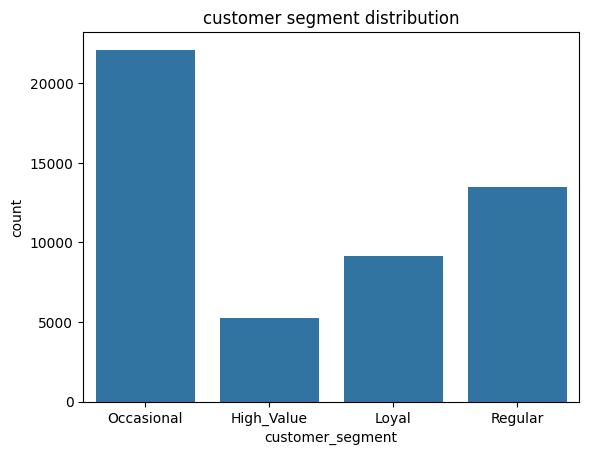

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="customer_segment")
plt.title("customer segment distribution")
plt.show
plt.savefig("customer segment distribution.png", bbox_inches="tight")
plt.show()

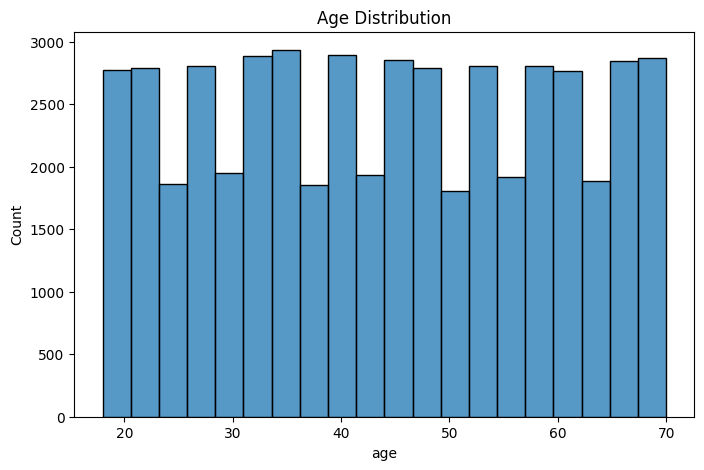

<Figure size 640x480 with 0 Axes>

In [73]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20)
plt.title("Age Distribution")
plt.show()
plt.savefig("Age Distribution.png", bbox_inches="tight")
plt.show()

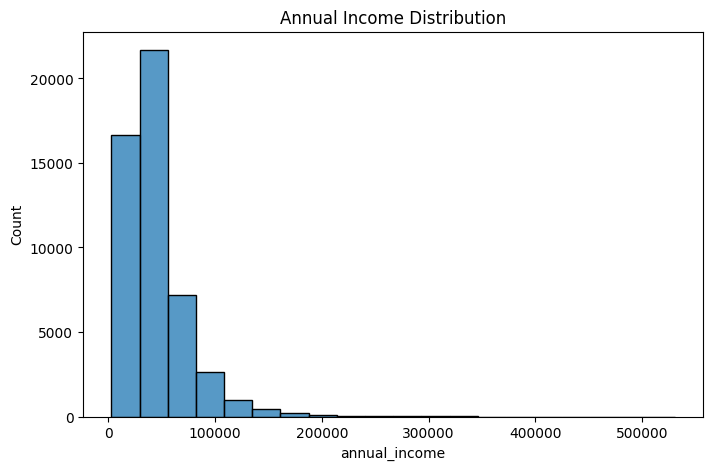

<Figure size 640x480 with 0 Axes>

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(df['annual_income'], bins=20)
plt.title("Annual Income Distribution")
plt.show()
plt.savefig("Annual Income Distribution.png", bbox_inches="tight")
plt.show()

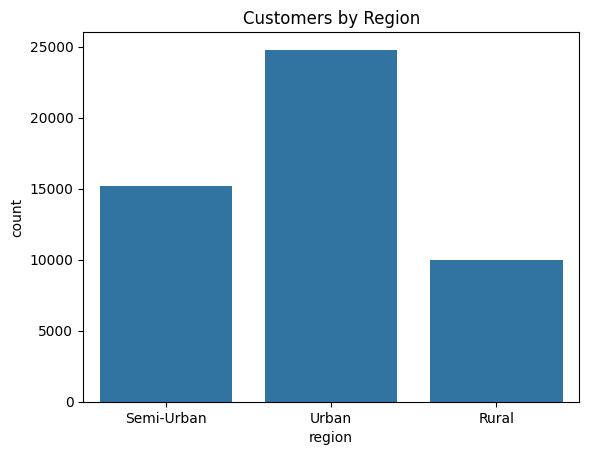

In [30]:
sns.countplot(data=df, x='region')
plt.title("Customers by Region")
plt.show()

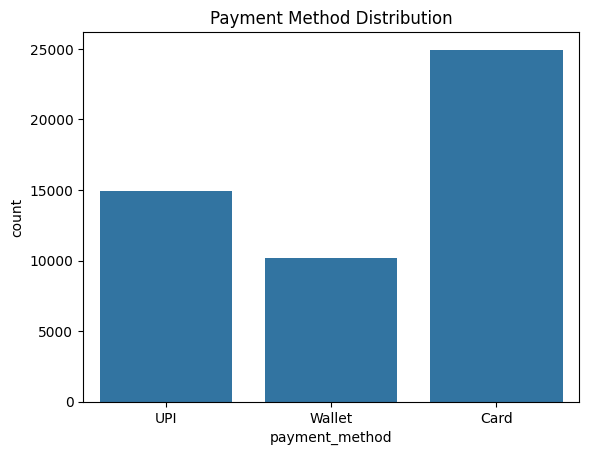

In [31]:
sns.countplot(data=df, x='payment_method')
plt.title("Payment Method Distribution")
plt.show()

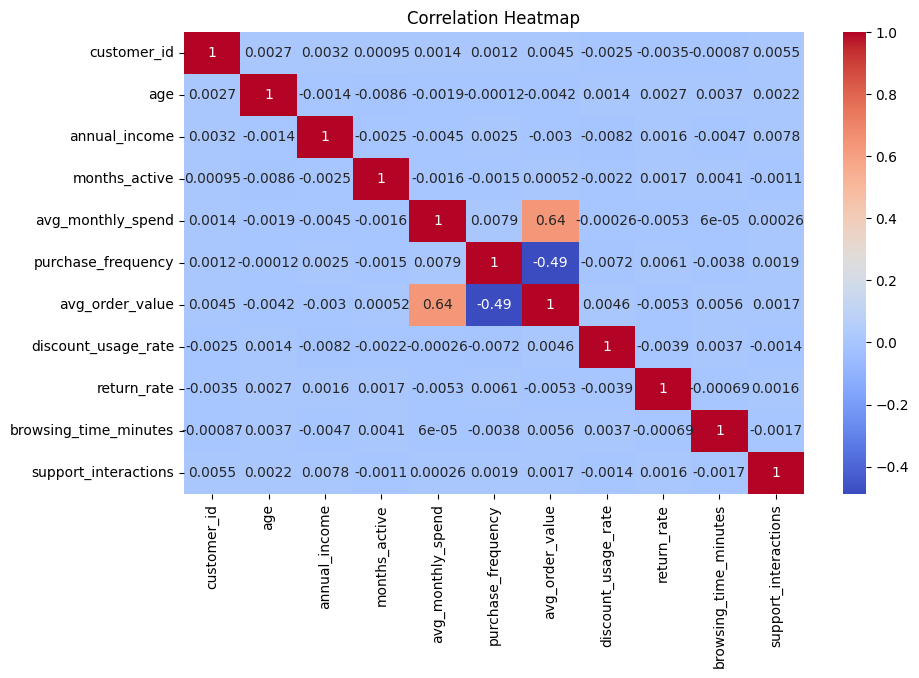

In [32]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [33]:
df['CLV'] = df['avg_monthly_spend'] * df['months_active']
df['Annual_Spend'] = df['avg_monthly_spend'] * 12
df[['CLV', 'Annual_Spend']].head()
df[['CLV', 'Annual_Spend']].describe()

,CLV,Annual_Spend
count,50000.000000,50000.000000
mean,12223.747619,4023.449630
std,10902.916390,2395.126713
min,32.093400,96.867600
25%,4345.376725,2366.650200
50%,9462.473350,3569.728800
75%,17018.046425,5150.299500
max,202764.927400,36316.106400


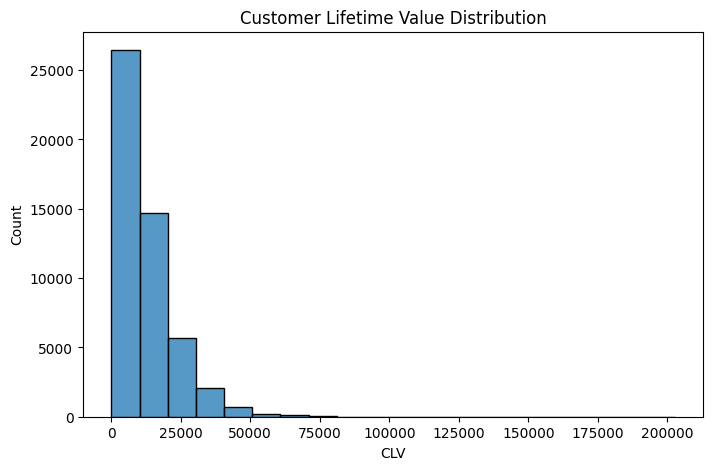

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['CLV'], bins=20)
plt.title("Customer Lifetime Value Distribution")
plt.show()

In [35]:
X = df[
    [
        'annual_income',
        'avg_monthly_spend',
        'purchase_frequency',
        'avg_order_value',
        'months_active',
        'CLV'
    ]
]

In [37]:
import sys
print(sys.executable)

C:\Users\nagen\AppData\Local\Programs\Python\Python314\python.exe


In [43]:
print("Scikit-learn imported successfully")

Scikit-learn imported successfully


In [44]:
X = df[
    [
        'annual_income',
        'avg_monthly_spend',
        'purchase_frequency',
        'avg_order_value',
        'months_active',
        'CLV'
    ]
]

In [46]:
X.head()

,annual_income,avg_monthly_spend,purchase_frequency,avg_order_value,months_active,CLV
0,89118.2139,269.5184,1.36,114.19,40,10780.7360
1,46508.3021,134.1236,14.15,8.85,72,9656.8992
2,36787.7300,377.4845,3.07,92.81,69,26046.4305
3,22823.1548,174.4329,8.88,17.66,72,12559.1688
4,61650.7947,143.4581,1.66,54.00,3,430.3743


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [49]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

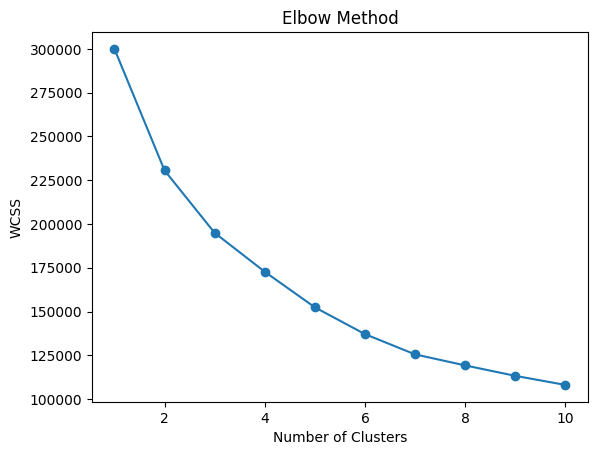

In [50]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [51]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [52]:
df['Cluster'].value_counts()

Cluster
3    16986
2    15583
1     6792
0     6768
4     3871
Name: count, dtype: int64

In [57]:
df.groupby('Cluster')[
    ['annual_income',
     'avg_monthly_spend',
     'purchase_frequency',
     'avg_order_value',
     'months_active',
     'CLV']
].mean()

,annual_income,avg_monthly_spend,purchase_frequency,avg_order_value,months_active,CLV
Cluster,,,,,,
0,40100.940660,308.403806,10.975706,27.155502,33.670508,10057.223713
1,41152.505984,658.648570,3.446310,188.237637,45.768110,29168.452923
2,36870.328252,266.754949,4.154079,59.893145,54.977540,14509.162869
3,36983.998538,287.608025,3.789432,71.198489,17.160544,4665.292109
4,116149.120197,300.026640,4.460222,68.148985,35.373547,10247.228588


In [58]:
segment_names = {
    0: "Frequent Buyers",
    1: "High Value",
    2: "Loyal Customers",
    3: "Occasional Customers",
    4: "High Income Potential"
}

df['Customer_Group'] = df['Cluster'].map(segment_names)

In [60]:
X = df[
    [
        'annual_income',
        'avg_monthly_spend',
        'purchase_frequency',
        'avg_order_value',
        'months_active',
        'CLV'
    ]
]

In [61]:
y = df['Customer_Group']

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [63]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [64]:
y_pred = model.predict(X_test)

In [65]:
from sklearn.model_selection import train_test_split

In [66]:
from sklearn.tree import DecisionTreeClassifier

In [67]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [68]:
y_pred = model.predict(X_test)

In [69]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9726


In [70]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                       precision    recall  f1-score   support

      Frequent Buyers       0.96      0.97      0.96      1315
High Income Potential       0.95      0.95      0.95       788
           High Value       0.96      0.96      0.96      1367
      Loyal Customers       0.98      0.98      0.98      3116
 Occasional Customers       0.98      0.98      0.98      3414

             accuracy                           0.97     10000
            macro avg       0.97      0.97      0.97     10000
         weighted avg       0.97      0.97      0.97     10000



In [71]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1269    2    8   19   17]
 [   7  748   16    8    9]
 [   3   16 1311   14   23]
 [  27    8   20 3047   14]
 [  14   14   16   19 3351]]
